In [1]:
import star, wind, cme, instrument,observation
from default_vals import bands
from astropy import units as un, constants as const
import matplotlib.pyplot as plt
import numpy as np

In [2]:
distance = 3.2 * un.pc
physical_size = 5*un.au
n_pix = 121
c, b = bands['H'].values()
h_band = [c - b/2, c + b/2]


/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0.5, 0.98, 'Photon flux from star at the earth')

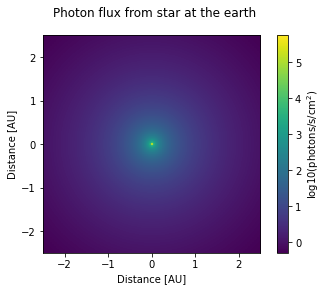

In [3]:
s = star.Star(temp=5080, radius=0.72*un.R_sun, distance=3.2*un.pc, linear_extent=physical_size, dim=n_pix, wavelength_range=h_band)
s.make_stellar_grids()
fig, ax = s.plot_stellar_flux()
fig.suptitle("Photon flux from star at the earth")

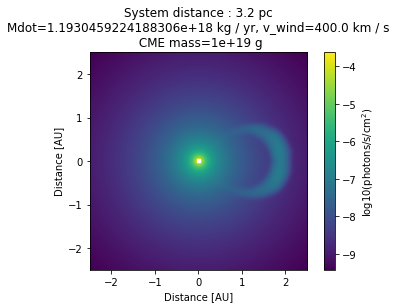

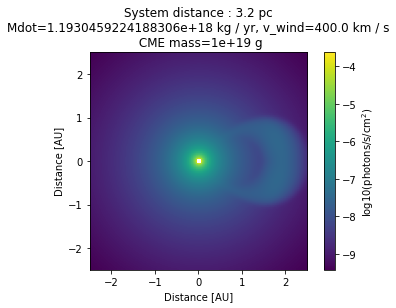

In [4]:
s.make_wind(Mdot=30*2e-14*const.M_sun/un.yr) # instantiates wind
s.make_cme(mass=1e19*un.g, horizontal_height_factor=2.3, dR_factor=0.2, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()

s.make_cme(mass=1e19*un.g, horizontal_height_factor=0.1, dR_factor=0.5, smear=True, smear_sig=n_pix/90) #instantiates CME
s.particle_to_photon_flux()
fig, ax = s.plot_particle_fluxes()

## Imaging

In [37]:
hwo = instrument.Instrument('H', name='HWO')
obs = observation.Observation(hwo, band = 'H', source_dim = 95)
obs.add_star()
obs.star.make_wind()
obs.star.make_cme(horizontal_height_factor=1., dR_factor=0.3, mass=1e25*un.g)
obs.conduct_observation()   

/home/idavis/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


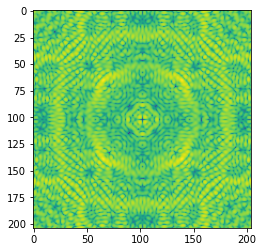

In [38]:
plt.imshow(np.log10(obs.img.intensity.reshape(obs.instrument.focal_grid.shape)))

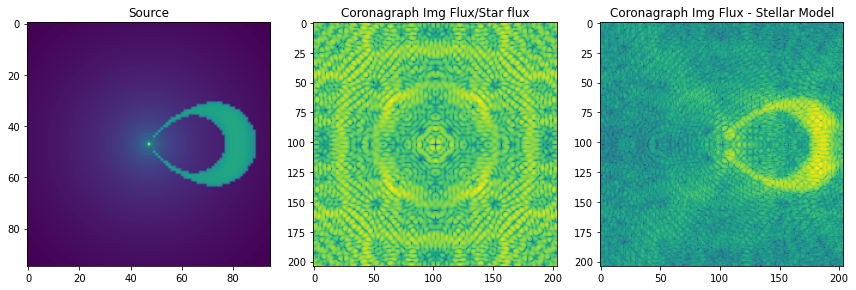

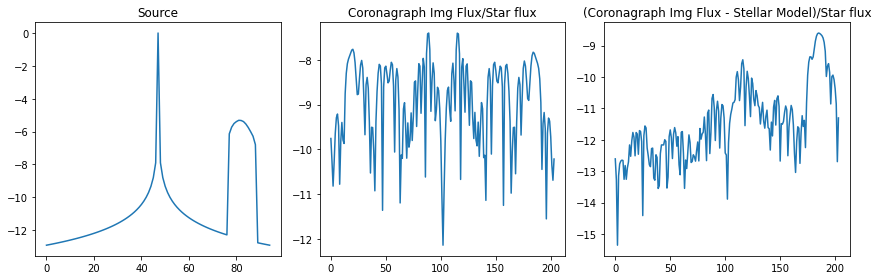

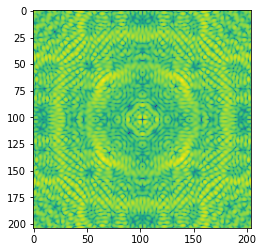

In [41]:
from hcipy import Wavefront
img = obs.img.intensity.reshape(obs.instrument.focal_grid.shape)
img_ref = obs.img_ref.intensity.reshape(obs.instrument.focal_grid.shape)

star_wf = Wavefront(obs.instrument.ap * np.nanmax(obs.source), wavelength=obs.centre_wave.to('m').value)
star_img = obs.instrument.prop(star_wf).intensity.reshape(obs.instrument.focal_grid.shape)
lyot_plane = obs.instrument.coronagraph(star_wf)
post_lyot_mask = obs.instrument.lyot_stop(lyot_plane)
star_cor_img = obs.instrument.prop(post_lyot_mask).intensity.reshape(obs.instrument.focal_grid.shape)


fig, axs = plt.subplots(1,3)
axs[0].imshow(np.log10(obs.source/obs.source.max()))
axs[1].imshow(np.log10(np.abs(img/img_ref.max())))
axs[2].imshow(np.log10(np.abs(img - star_cor_img)))

axs[0].set_title("Source")
axs[1].set_title("Coronagraph Img Flux/Star flux")
axs[2].set_title("Coronagraph Img Flux - Stellar Model")
fig.set_figwidth(12)
fig.set_figheight(8)
fig.tight_layout()

fig, axs = plt.subplots(1,3)
center = int(obs.instrument.focal_grid.shape[0]/2)
axs[0].plot(np.log10(obs.source/obs.source.max())[int(obs.star.grid_cme_photons.shape[0]/2),:])
axs[1].plot(np.log10(np.abs(img/img_ref.max()))[center,:])
axs[2].plot(np.log10(np.abs(img - star_cor_img)/img_ref.max())[center,:])

axs[0].set_title("Source")
axs[1].set_title("Coronagraph Img Flux/Star flux")
axs[2].set_title("(Coronagraph Img Flux - Stellar Model)/Star flux")
fig.set_figwidth(12)
fig.set_figheight(4)
fig.tight_layout()
    
